In [1]:
import os

%cd /content
!rm -rf SMADIMO_GP5

!git clone https://github.com/mnedo/SMADIMO_GP5.git

%cd SMADIMO_GP5
!git checkout eda/oskelly

/content
Cloning into 'SMADIMO_GP5'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 126 (delta 0), reused 0 (delta 0), pack-reused 125 (from 2)
Receiving objects: 100% (126/126), 67.22 MiB | 21.44 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/SMADIMO_GP5
Branch 'eda/oskelly' set up to track remote branch 'eda/oskelly' from 'origin'.
Switched to a new branch 'eda/oskelly'


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
DATA_DIR = "/content/SMADIMO_GP5/data/raw/oskelly_dataset.xlsx"

In [4]:
df = pd.read_excel(DATA_DIR)

print(df.shape)
print(df.columns.tolist())

(9600, 23)
['Oskelly ID', 'url', 'Размер', 'Раздел', 'Категория', 'Бренд', 'Материал одежды', 'Цвет', 'Состояние товара', 'Продавец', 'Цена', 'Скидка', 'Описание', 'Название', 'Состояние', 'image_url', 'image_path', 'Посадка', 'Материал джинсов', 'Модель', 'Винтаж', 'Материал футболок', 'Материал рубашек']


In [5]:
df.head(3)

,Oskelly ID,url,Размер,Раздел,Категория,Бренд,Материал одежды,Цвет,Состояние товара,Продавец,...,Название,Состояние,image_url,image_path,Посадка,Материал джинсов,Модель,Винтаж,Материал футболок,Материал рубашек
0,3136231,https://oskelly.ru/products/pukhovik-brunelloc...,IT 40,Женское,Пуховики,BRUNELLO CUCINELLI,Кожа,Розовый,Отличное состояние,Частный продавец,...,BRUNELLO CUCINELLIРозовый кожаный пуховикРозов...,Отличное состояние,https://static.cdn.oskelly.ru/product/3136231/...,D:\GP5\oskelly_images\3136231.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1,3653158,https://oskelly.ru/products/dzhemper--sviter-b...,IT 40,Женское,Джемперы и свитеры,BRUNELLO CUCINELLI,Кашемир,Серый,Отличное состояние,Частный продавец,...,BRUNELLO CUCINELLIСерый кашемировый джемпер / ...,Отличное состояние,https://static.cdn.oskelly.ru/product/3653158/...,D:\GP5\oskelly_images\3653158.jpg,NaN,NaN,NaN,NaN,NaN,NaN
2,5392952,https://oskelly.ru/products/bryuki-uzkie-twin-...,IT 40/42/44,Женское,Брюки узкие,TWIN-SET,Вискоза,Темно-синий,Новое с биркой,Бутик,...,TWIN-SETТемно-синие вискозные брюки узкиеТемно...,Новое с биркой,https://static.cdn.oskelly.ru/product/5392952/...,D:\GP5\oskelly_images\5392952.jpg,Средняя,NaN,NaN,NaN,NaN,NaN


Посмотрим на пропуски

In [6]:
print(df.isnull().sum().sort_values(ascending=False))

Винтаж               9515
Модель               9457
Материал рубашек     9099
Материал джинсов     9074
Посадка              8095
Материал футболок    7997
Материал одежды      2697
Скидка               1733
Описание                3
image_path              1
Категория               0
Oskelly ID              0
url                     0
Раздел                  0
Размер                  0
Бренд                   0
Название                0
Состояние               0
Цена                    0
Состояние товара        0
Цвет                    0
Продавец                0
image_url               0
dtype: int64


Почистим некоторые ключевые признаки. Избавимся от лишних пробелов и пропусков

In [7]:
df["Скидка"] = (df["Скидка"].fillna(0).astype(str).str.replace("%", "", regex=False).astype(int).abs())

In [8]:
df['Описание'] = df['Описание'].fillna('').str.strip()

In [9]:
df['Название'] = df['Название'].fillna('').str.strip()

In [10]:
df['Состояние товара'] = df['Состояние товара'].str.strip()

Удалим дубликаты по ИД

In [11]:
df = df.drop_duplicates(subset='Oskelly ID')

In [12]:
df.head()

,Oskelly ID,url,Размер,Раздел,Категория,Бренд,Материал одежды,Цвет,Состояние товара,Продавец,...,Название,Состояние,image_url,image_path,Посадка,Материал джинсов,Модель,Винтаж,Материал футболок,Материал рубашек
0,3136231,https://oskelly.ru/products/pukhovik-brunelloc...,IT 40,Женское,Пуховики,BRUNELLO CUCINELLI,Кожа,Розовый,Отличное состояние,Частный продавец,...,BRUNELLO CUCINELLIРозовый кожаный пуховикРозов...,Отличное состояние,https://static.cdn.oskelly.ru/product/3136231/...,D:\GP5\oskelly_images\3136231.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1,3653158,https://oskelly.ru/products/dzhemper--sviter-b...,IT 40,Женское,Джемперы и свитеры,BRUNELLO CUCINELLI,Кашемир,Серый,Отличное состояние,Частный продавец,...,BRUNELLO CUCINELLIСерый кашемировый джемпер / ...,Отличное состояние,https://static.cdn.oskelly.ru/product/3653158/...,D:\GP5\oskelly_images\3653158.jpg,NaN,NaN,NaN,NaN,NaN,NaN
2,5392952,https://oskelly.ru/products/bryuki-uzkie-twin-...,IT 40/42/44,Женское,Брюки узкие,TWIN-SET,Вискоза,Темно-синий,Новое с биркой,Бутик,...,TWIN-SETТемно-синие вискозные брюки узкиеТемно...,Новое с биркой,https://static.cdn.oskelly.ru/product/5392952/...,D:\GP5\oskelly_images\5392952.jpg,Средняя,NaN,NaN,NaN,NaN,NaN
3,3904378,https://oskelly.ru/products/bluzy-brunellocuci...,INT S,Женское,Блузы,BRUNELLO CUCINELLI,Шелк,Мульти,Отличное состояние,Частный продавец,...,BRUNELLO CUCINELLIМульти шелковая блузыМульти ...,Отличное состояние,https://static.cdn.oskelly.ru/product/3904378/...,D:\GP5\oskelly_images\3904378.jpg,NaN,NaN,NaN,NaN,NaN,NaN
4,4034222,https://oskelly.ru/products/yubka-maksi-brunel...,IT 38,Женское,Юбки макси,BRUNELLO CUCINELLI,Шелк,Серый,Новое с биркой,Частный продавец,...,BRUNELLO CUCINELLIСерая шелковая юбка максиСер...,Новое с биркой,https://static.cdn.oskelly.ru/product/4034222/...,D:\GP5\oskelly_images\4034222.jpg,NaN,NaN,NaN,NaN,NaN,NaN


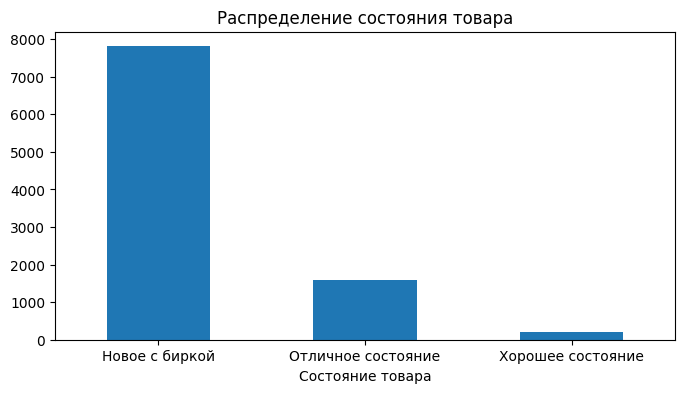

In [13]:
df["Состояние товара"].value_counts().plot(kind="bar", figsize=(8, 4))
plt.title("Распределение состояния товара")
plt.xticks(rotation=0)
plt.show()

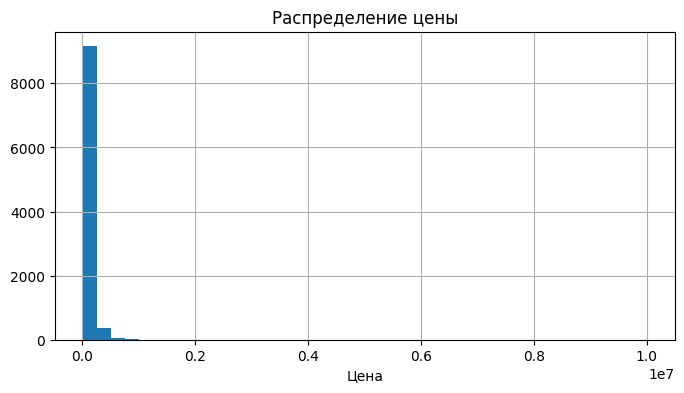

count        9600.0
mean        83754.0
std        213758.0
min          9996.0
25%         25971.0
50%         47212.0
75%         90276.0
max      10000000.0
Name: Цена, dtype: float64


In [14]:
df["Цена"].hist(bins=40, figsize=(8, 4))
plt.title("Распределение цены")
plt.xlabel("Цена")
plt.show()
print(df["Цена"].describe().round(0))

Распределение цены имеет большой правый хвост. Попробуем прологарифмировать

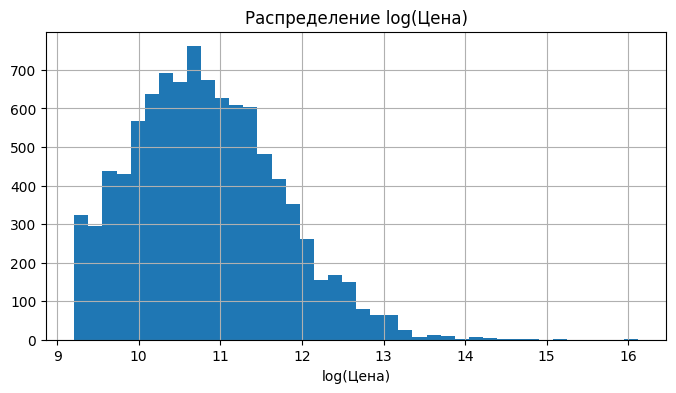

count        9600.0
mean        83754.0
std        213758.0
min          9996.0
25%         25971.0
50%         47212.0
75%         90276.0
max      10000000.0
Name: Цена, dtype: float64


In [15]:
np.log1p(df["Цена"]).hist(bins=40, figsize=(8, 4))
plt.title("Распределение log(Цена)")
plt.xlabel("log(Цена)")
plt.show()
print(df["Цена"].describe().round(0))

Цены распределены неравномерно

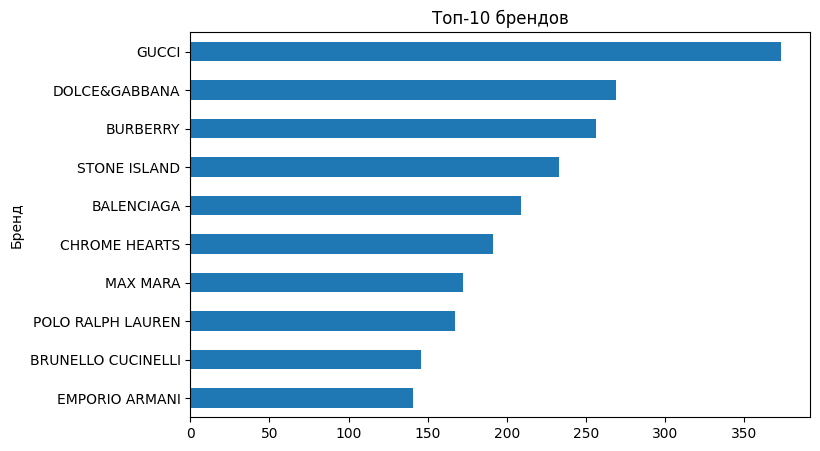

In [16]:
df["Бренд"].value_counts().head(10).plot(kind="barh", figsize=(8, 5))
plt.title("Топ-10 брендов")
plt.gca().invert_yaxis()
plt.show()

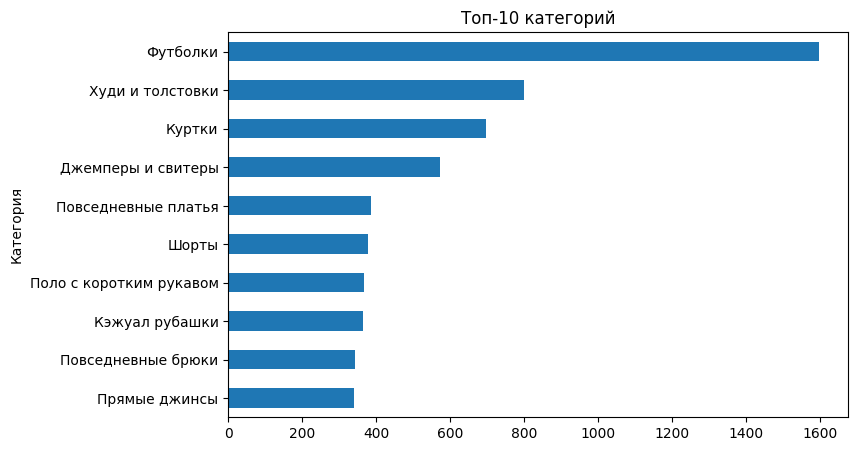

In [17]:
df["Категория"].value_counts().head(10).plot(kind="barh", figsize=(8, 5))
plt.title("Топ-10 категорий")
plt.gca().invert_yaxis()
plt.show()

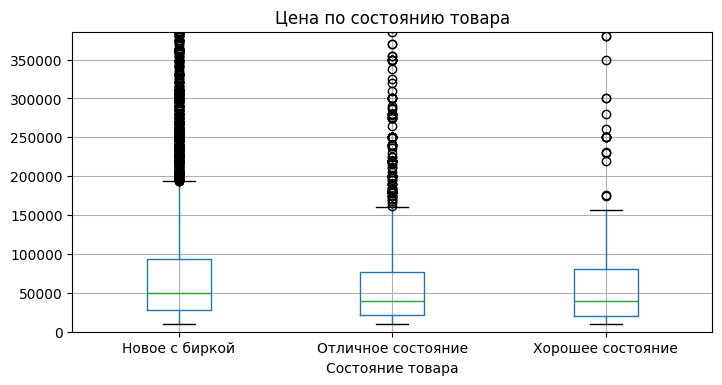

In [18]:
df.boxplot(column="Цена", by="Состояние товара", figsize=(8, 4))
plt.ylim(0, df["Цена"].quantile(0.98))
plt.title("Цена по состоянию товара")
plt.suptitle("")
plt.show()

In [19]:
!pip install sentence-transformers -q

In [20]:
from sentence_transformers import SentenceTransformer
import re

In [21]:
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Уберем эмодзи из описаний

In [22]:
def remove_emoji(text):
    if not isinstance(text, str):
        return ''
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA70-\U0001FAFF"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', text)

df['Описание'] = df['Описание'].apply(remove_emoji)

In [23]:
texts = df['Описание'].tolist()
embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(embeddings.shape)

Batches:   0%|          | 0/150 [00:00<?, ?it/s]

(9600, 384)


Подготовим выбросы для обучения

Избавимся от выбросов в цене

In [24]:
mask = df['Цена'] <= 300000
df = df[mask].reset_index(drop=True)
embeddings = embeddings[mask]

In [25]:
y = np.log1p(df['Цена'].values)

In [26]:
razdel = (df['Раздел'] == 'Женское').astype(int).values

In [27]:
condition_map = {
    'Хорошее состояние': 0,
    'Отличное состояние': 1,
    'Новое с биркой': 2,
}
sostoyanie = df['Состояние товара'].map(condition_map).values

In [28]:
skidka = df['Скидка'].values / 100.0

In [29]:
prodavec_dummies = pd.get_dummies(df['Продавец'], prefix='prodavec', dtype=float)

In [30]:
color_dummies = pd.get_dummies(df['Цвет'], prefix='color', dtype=float)

In [31]:
material = df['Материал одежды'].fillna('Не указан')
material_dummies = pd.get_dummies(material, prefix='material', dtype=float)

In [32]:
kategoriya_dummies = pd.get_dummies(df['Категория'], prefix='kat', dtype=float)

In [33]:
top70_brands = df['Бренд'].value_counts().head(70).index
brand_col = df['Бренд'].where(df['Бренд'].isin(top70_brands), other='Other')
brand_dummies = pd.get_dummies(brand_col, prefix='brand', dtype=float)

In [34]:
np.save('text_embeddings.npy', embeddings)
df.to_csv('oskelly_clean.csv', index=False)

In [35]:
tab = np.hstack([
    razdel.reshape(-1, 1),
    sostoyanie.reshape(-1, 1),
    skidka.reshape(-1, 1),
    prodavec_dummies.values,
    color_dummies.values,
    material_dummies.values,
    kategoriya_dummies.values,
    brand_dummies.values,
])

In [36]:
X = np.hstack([embeddings, tab]).astype(np.float32)
y = y.astype(np.float32)

In [37]:
np.save('X.npy', X)
np.save('y.npy', y)

In [38]:
from datasets import load_dataset

dataset = load_dataset("wargoninnovation/clothingdatasetsecondhand")
train_data = dataset["train"]
test_data = dataset["test"]


README.md:   0%|          | 0.00/15.0k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/450M [00:00<?, ?B/s]

data/test-00000-of-00002.parquet:   0%|          | 0.00/383M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/384M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30192 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12940 [00:00<?, ? examples/s]

Посмотрим на распределение классов

In [39]:
train_conditions = dataset['train']['condition']
print(pd.Series(train_conditions).value_counts().sort_index())

1     1233
2     6150
3    10113
4     4649
5     8047
Name: count, dtype: int64


In [40]:
test_conditions = dataset['test']['condition']
print(pd.Series(test_conditions).value_counts().sort_index())

1     499
2    2666
3    4287
4    2017
5    3471
Name: count, dtype: int64


Поменяем классы в соответствии с нашим Oskelly

In [41]:
label_names = {0: 'Хорошее состояние', 1: 'Отличное состояние', 2: 'Новое'}
dataset = dataset.map(lambda x: {"label": 0 if x["condition"] <= 2 else 1 if x["condition"] <= 4 else 2})
print(pd.Series(dataset['train']['label']).value_counts().sort_index().rename(label_names))

Map:   0%|          | 0/30192 [00:00<?, ? examples/s]

Map:   0%|          | 0/12940 [00:00<?, ? examples/s]

Хорошее состояние      7383
Отличное состояние    14762
Новое                  8047
Name: count, dtype: int64


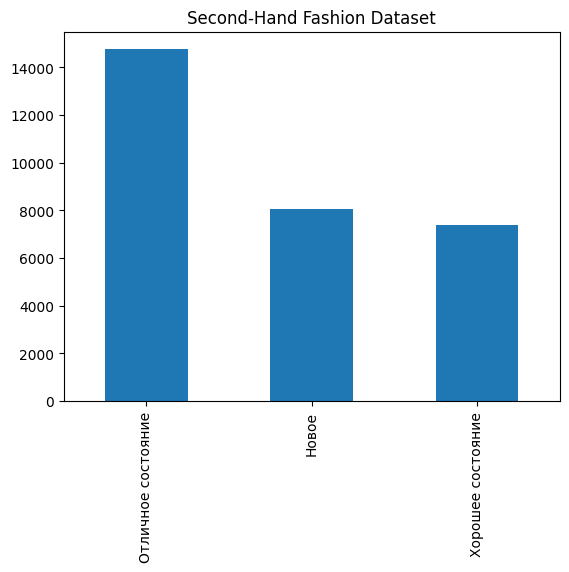

In [42]:
fashion_cnt = pd.Series(dataset['train']['label']).map(label_names).value_counts()
fashion_cnt.plot(kind='bar', title='Second-Hand Fashion Dataset')
plt.show()

Уберем ненужные признаки

In [43]:
dataset = dataset.select_columns(["image", "condition", "description"])

print(dataset['train'].column_names)
print(dataset['test'].column_names)

['image', 'condition', 'description']
['image', 'condition', 'description']


Проверим количество наблюдений с пустыми описаниями

In [44]:
empty = sum(pd.Series(dataset['train']['description']).fillna('').str.strip() == '')
print("Пустых описаний:", empty)
empty = sum(pd.Series(dataset['test']['description']).fillna('').str.strip() == '')
print("Пустых описаний:", empty)

Пустых описаний: 13973
Пустых описаний: 5933


Удалим наблюдения без описания

In [45]:
dataset = dataset.filter(lambda x: x['description'] is not None and x['description'].strip() != '')

Filter:   0%|          | 0/30192 [00:00<?, ? examples/s]

Filter:   0%|          | 0/12940 [00:00<?, ? examples/s]

In [46]:
empty = sum(pd.Series(dataset['train']['description']).fillna('').str.strip() == '')
print("Пустых описаний:", empty)
empty = sum(pd.Series(dataset['test']['description']).fillna('').str.strip() == '')
print("Пустых описаний:", empty)

Пустых описаний: 0
Пустых описаний: 0


In [47]:
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [48]:
texts_train = dataset['train']['description']
texts_test = dataset['test']['description']

X_train_text = model.encode(
    texts_train,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

X_test_text = model.encode(
    texts_test,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/254 [00:00<?, ?it/s]

Batches:   0%|          | 0/110 [00:00<?, ?it/s]

In [ ]:
os.makedirs("fashion_data")

In [ ]:
np.save("fashion_data/X_train_text.npy", X_train_text)
np.save("fashion_data/X_test_text.npy", X_test_text)

In [ ]:
from google.colab import drive
drive.mount('/drive')

In [56]:
!cp "/drive/MyDrive/GP5_EDA.ipynb" /content/SMADIMO_GP5/notebooks/GP5_EDA.ipynb
!git add notebooks/GP5_EDA.ipynb
!git commit -m "EDA: обновлён ноутбук"
!git push origin eda/oskelly

cp: cannot stat '/drive/MyDrive/GP5_EDA.ipynb': No such file or directory
On branch eda/oskelly
Your branch is up to date with 'origin/eda/oskelly'.

nothing to commit, working tree clean
Everything up-to-date
